In [10]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd


import os

os.environ["OMP_NUM_THREADS"] = "4"

print(os.environ["OMP_NUM_THREADS"])
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

4


In [11]:
iris=load_iris()

In [12]:
X=iris.data
 
y=iris.target

<Axes: >

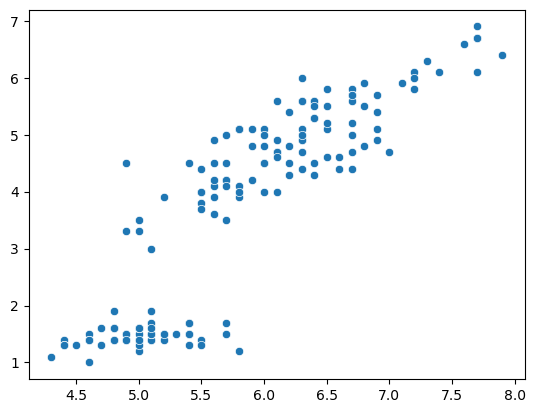

In [13]:

sns.scatterplot(x=X[:,0],y=X[:,2])

In [24]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_scaled=scalar.fit_transform(X)

In [25]:
#optional -dimensionality reducation using PCA
from sklearn.decomposition import PCA


pca =PCA(n_components=2)
pca_data =pca.fit(X_scaled)

In [27]:
#Elbow point

wcss=[]
for i in range(1, 21):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    #in the inertia we get the all stores values for wcss

<Axes: >

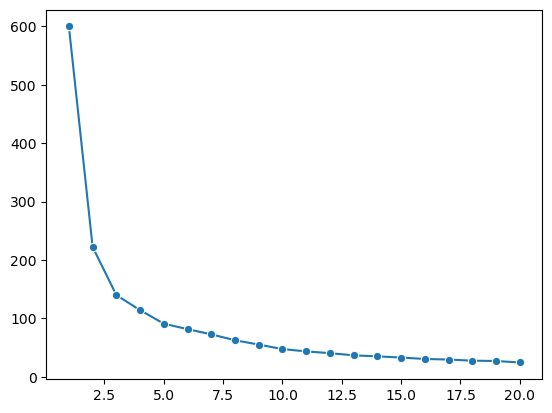

In [28]:
sns.lineplot(x=range(1,21), y=wcss, marker='o')

In [38]:
#Kmeans
k=3
kmeans=KMeans(
    n_clusters=k, 
    random_state=42,
     
)
lables=kmeans.fit_predict(X_scaled)


<Axes: >

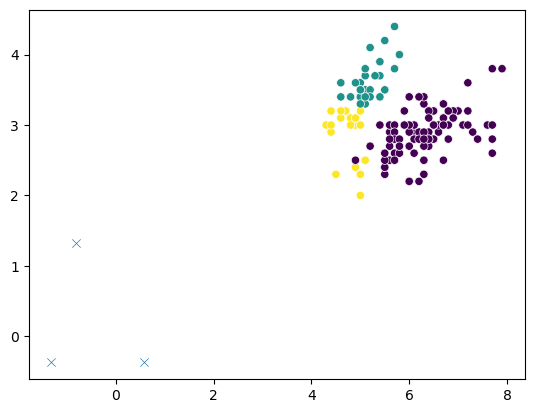

In [39]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=lables)
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker="x")
